# Regresión Logística con la base de datos Breast Cancer (sklearn)

En esta guía aprenderemos a implementar un modelo de **Regresión Logística** para predecir si un tumor es **maligno** o **benigno** utilizando la base de datos *Breast Cancer* incluida en `sklearn`. La base que se carga con from sklearn.datasets import load_breast_cancer corresponde a la Breast Cancer Wisconsin (Diagnostic) Dataset, comúnmente conocida como Wisconsin Breast Cancer Dataset.

📌 Detalles principales

Origen: Wisconsin Diagnostic Breast Cancer (WDBC).

Fuente: UCI Machine Learning Repository (donada por el Dr. William H. Wolberg, University of Wisconsin Hospitals, Madison).

La regresión logística es un modelo de **clasificación binaria** que estima la probabilidad de que una observación pertenezca a una de dos clases (0 o 1).  
En este caso, nuestro objetivo será clasificar los tumores en:

* **0 = Maligno**
* **1 = Benigno**

El flujo de trabajo será:
1. Cargar y explorar los datos.
2. Describir las variables.
3. Dividir en conjuntos de entrenamiento y prueba.
4. Escalar los datos.
5. Entrenar el modelo de regresión logística.
6. Evaluar el rendimiento del modelo.

---


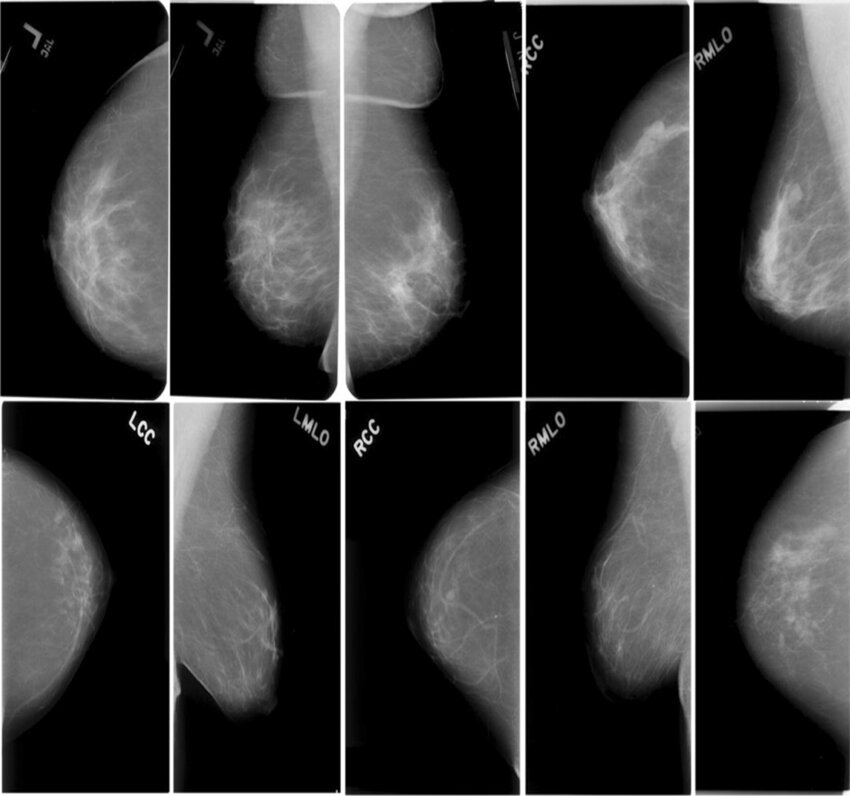

## Descripción de las Variables

La base de datos contiene **569 muestras** y **30 características** numéricas calculadas a partir de imágenes de células mamarias.

Cada variable describe propiedades de los núcleos de las células. Las principales son:

- **mean radius**: Radio medio de las células.
- **mean texture**: Desviación estándar de los valores de escala de grises.
- **mean perimeter**: Perímetro medio.
- **mean area**: Área media.
- **mean smoothness**: Variación local en el radio.
- **mean compactness**: Relación perímetro²/área − 1.0.
- **mean concavity**: Severidad de las concavidades del contorno.
- **mean concave points**: Número de concavidades del contorno.
- **mean symmetry**: Simetría de la célula.
- **mean fractal dimension**: Dimensión fractal aproximada.

> Además, cada una de estas medidas tiene versiones de **error** y **peor caso (worst)**, completando las 30 variables.

La **variable objetivo (target)** indica:
* `0`: Tumor **maligno**
* `1`: Tumor **benigno**

In [17]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Vista inicial
print("Dimensiones de X:", X.shape)
X.head()


Dimensiones de X: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
# Información general
print(X.info())

# Resumen estadístico
X.describe().T.head(10)

# Distribución de la variable objetivo
y.value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,proportion
1,0.627417
0,0.372583



📊 Distribución de la variable objetivo (0=Maligno, 1=Benigno):
1    357
0    212
Name: count, dtype: int64

Proporción porcentual:
1    62.741652
0    37.258348
Name: proportion, dtype: float64


/tmp/ipython-input-3050807663.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


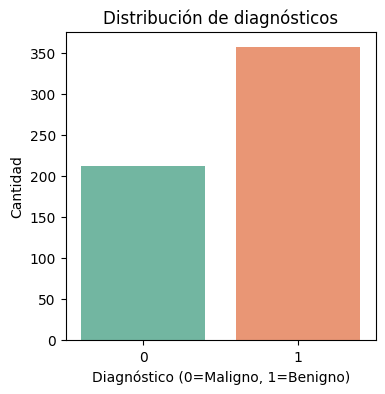


📈 Estadísticas descriptivas de las variables:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


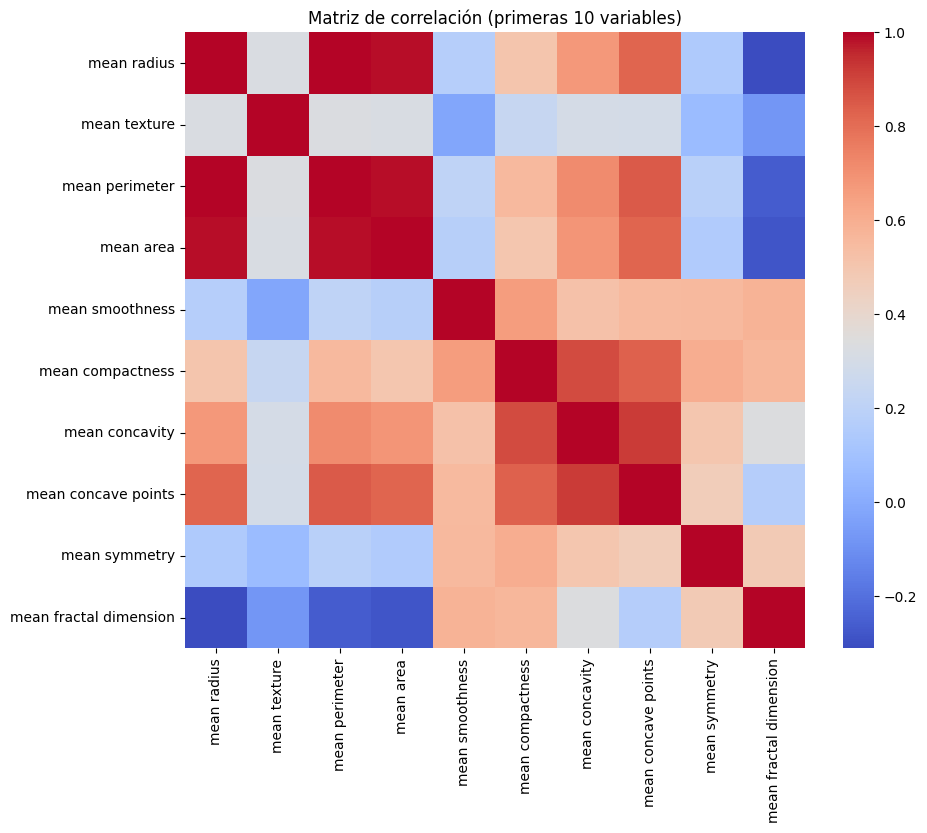

In [19]:
# 3. Distribución de la variable objetivo
print("\n📊 Distribución de la variable objetivo (0=Maligno, 1=Benigno):")
print(y.value_counts())
print("\nProporción porcentual:")
print(y.value_counts(normalize=True)*100)

# Gráfico de barras de la variable objetivo
plt.figure(figsize=(4,4))
sns.countplot(x=y, palette="Set2")
plt.title("Distribución de diagnósticos")
plt.xlabel("Diagnóstico (0=Maligno, 1=Benigno)")
plt.ylabel("Cantidad")
plt.show()

# 4. Estadísticas descriptivas de las variables
print("\n📈 Estadísticas descriptivas de las variables:")
display(X.describe().T)  # .T para ver variables en filas

# 5. Matriz de correlación (opcional: solo para las primeras 10 variables para mejor visualización)
plt.figure(figsize=(10,8))
sns.heatmap(X.iloc[:, :10].corr(), annot=False, cmap="coolwarm")
plt.title("Matriz de correlación (primeras 10 variables)")
plt.show()

In [11]:
# Separar en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)


Tamaño entrenamiento: (398, 30)
Tamaño prueba: (171, 30)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# Crear y entrenar modelo
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train_scaled, y_train)

# Coeficientes
pd.DataFrame({
    "Variable": data.feature_names,
    "Coeficiente": log_model.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False).head(10)


,Variable,Coeficiente
21,worst texture,-1.226329
27,worst concave points,-0.996807
23,worst area,-0.954956
20,worst radius,-0.941060
13,area error,-0.937493
10,radius error,-0.886370
28,worst symmetry,-0.869444
26,worst concavity,-0.785989
24,worst smoothness,-0.748971
22,worst perimeter,-0.731042


## Resumen de los Coeficientes del Modelo de Regresión Logística

Los coeficientes de la regresión logística indican el efecto de cada variable sobre el **logaritmo de las odds** (log-odds) de que el tumor sea **benigno** (clase 1).  
En este modelo, **todos los coeficientes son negativos**, lo que significa que **a mayor valor de estas características, disminuye la probabilidad de que el tumor sea benigno** y, por tanto, aumenta la probabilidad de malignidad.

### Puntos clave

- **Signo negativo**  
  - Un coeficiente negativo implica que el aumento de la variable se asocia con un mayor riesgo de **malignidad**.  
  - Por ejemplo, un incremento en `worst texture` o `worst concave points` reduce la probabilidad de que el tumor sea benigno.

- **Magnitud del coeficiente**  
  - Mientras mayor sea el valor absoluto del coeficiente, mayor influencia ejerce esa variable sobre la clasificación.
  - La variable **worst texture** (coef. ≈ -1.23) es la de mayor peso, seguida de otras mediciones como `worst concave points`, `worst area` y `worst radius`.

### Interpretación de variables principales

- **worst texture**: Un aumento de una unidad reduce significativamente las odds de benignidad (mayor irregularidad de la textura → mayor probabilidad de malignidad).  
- **worst concave points**: Más puntos cóncavos en el contorno del tumor aumentan el riesgo de malignidad.  
- **worst area y worst radius**: Tumores con mayor área y radio en su peor medición tienen alta asociación con malignidad.  
- **area error y radius error**: Mayor variabilidad en área o radio también incrementa el riesgo.

### Conclusión

El modelo identifica que las características de tamaño, forma e irregularidad en su **peor medición** son las más determinantes para diferenciar entre tumores benignos y malignos.  
En términos clínicos, esto concuerda con la evidencia de que los tumores malignos suelen presentar **mayor tamaño, irregularidad y heterogeneidad** en sus células.


In [14]:
# Predicciones
y_pred = log_model.predict(X_test_scaled)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)

# Reporte de clasificación
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# Exactitud
print("Exactitud del modelo:", accuracy_score(y_test, y_pred))


Matriz de confusión:
 [[ 63   1]
 [  1 106]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171

Exactitud del modelo: 0.9883040935672515


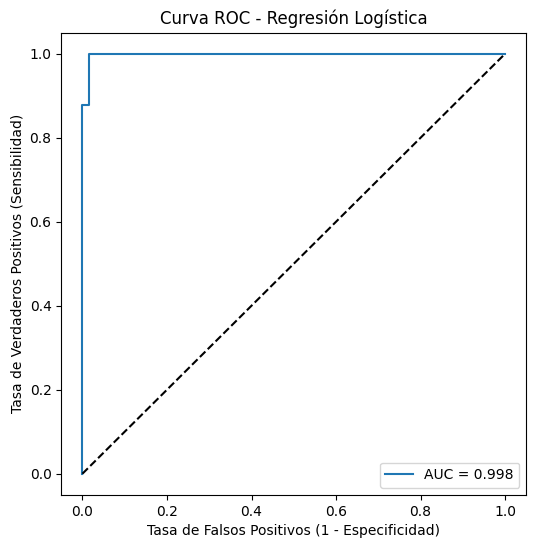

In [15]:


# Probabilidades para la clase positiva
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# Calcular puntos de la curva
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Graficar
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  # Línea de referencia
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()


## Conclusión

El modelo de **Regresión Logística** alcanzó un desempeño sobresaliente, con una **exactitud global del 98,8 %** en el conjunto de prueba.  
Los valores de **precisión, recall y F1-score** fueron muy altos para ambas clases (maligno y benigno), situándose en torno al **0.98–0.99**, lo que indica:

- **Alta precisión**: el modelo casi no genera falsos positivos, clasificando correctamente la mayoría de los casos predichos como malignos o benignos.  
- **Excelente recall (sensibilidad)**: la capacidad de detectar correctamente los tumores de cada tipo es casi perfecta, minimizando los falsos negativos.  
- **Equilibrio entre métricas**: el macro y weighted average cercanos a 0.99 demuestran que el rendimiento es consistente, incluso ante el leve desbalance de clases.

En conjunto, estos resultados confirman que la regresión logística es una herramienta **eficaz y confiable** para la predicción del tipo de tumor en esta base de datos, siempre que se mantenga un adecuado preprocesamiento y estandarización de las variables.

